In [1]:
# importing the necessary Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the csv file into a DataFrame
df = pd.read_csv(r"C:\Users\SUKDEB MUKHERJEE\Downloads\Diwali Sales Data.csv",encoding="unicode_escape")
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


## Inspecting and cleaning the dataset

In [4]:
df.shape

(11251, 15)

In [5]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='str')

In [6]:
# General summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [7]:
# Statistical summary of all the numerical columns of the dataset
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [8]:
# Checking if there are any duplicate records in dataset
df.duplicated().sum()

np.int64(8)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Checking if there are any missing or null values in the dataset
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11243
unnamed1            11243
dtype: int64

In [12]:
df.drop(["Status","unnamed1"],axis=1,inplace=True)

In [13]:
df.dropna(inplace=True)

# Exploratory Data Analysis

### Gender

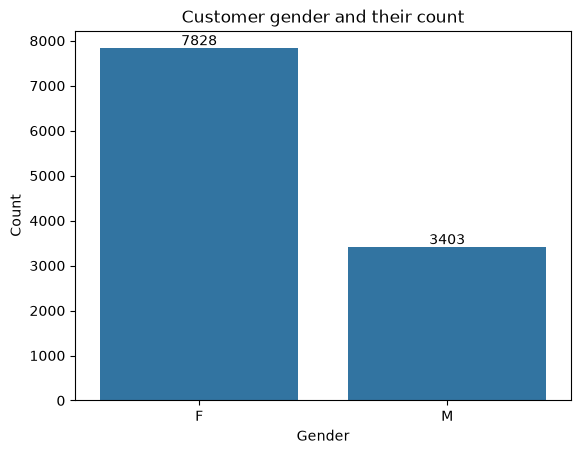

In [15]:
# Plotting a bar chart for gender and its count
ax = sns.countplot(x = df["Gender"])
plt.title("Customer gender and their count")
plt.ylabel("Count")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

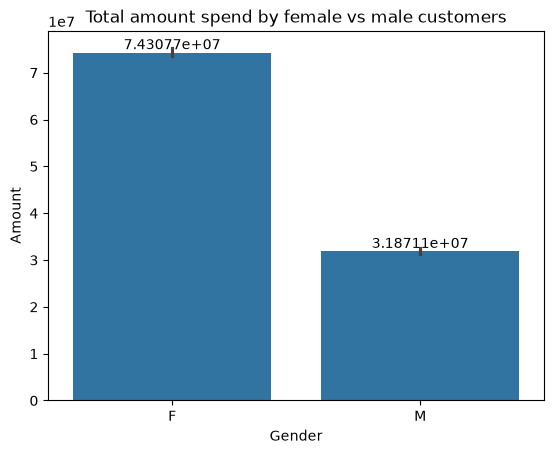

In [16]:
# Plotting a bar chart for gender vs total amount
ax = sns.barplot(x="Gender",y="Amount",data=df,estimator=sum)
plt.title("Total amount spend by female vs male customers")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

**From the above graphs, we can see that most of the buyers are females and even the purchasing power of female are greater than that of men** 

### Age

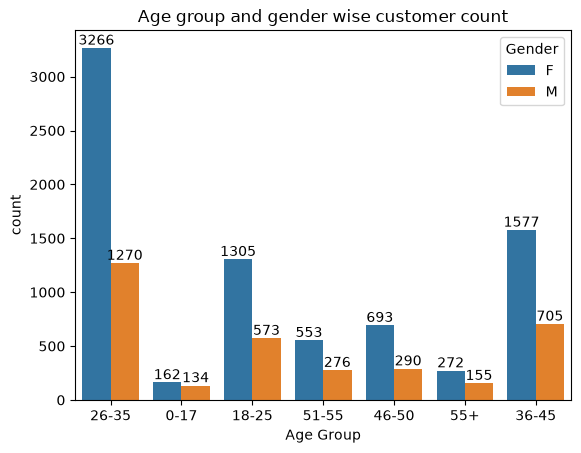

In [19]:
# Age group and gender wise customer count
ax = sns.countplot(x="Age Group",hue="Gender",data=df)
plt.title("Age group and gender wise customer count")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

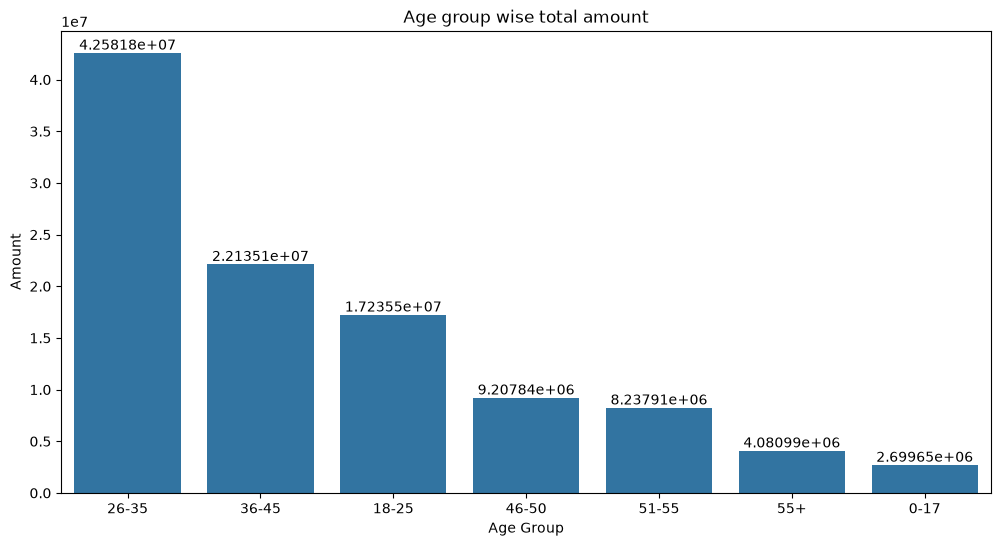

In [24]:
# Total amount vs age group
df1 = pd.DataFrame(df.groupby("Age Group")["Amount"].sum().sort_values(ascending=False))
plt.figure(figsize=(12,6))
ax = sns.barplot(x="Age Group",y="Amount",data=df1)
plt.title("Age group wise total amount")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

**From the above graphs we can see that most of the buyers are female and are of age group between 26-35 years old**

### State

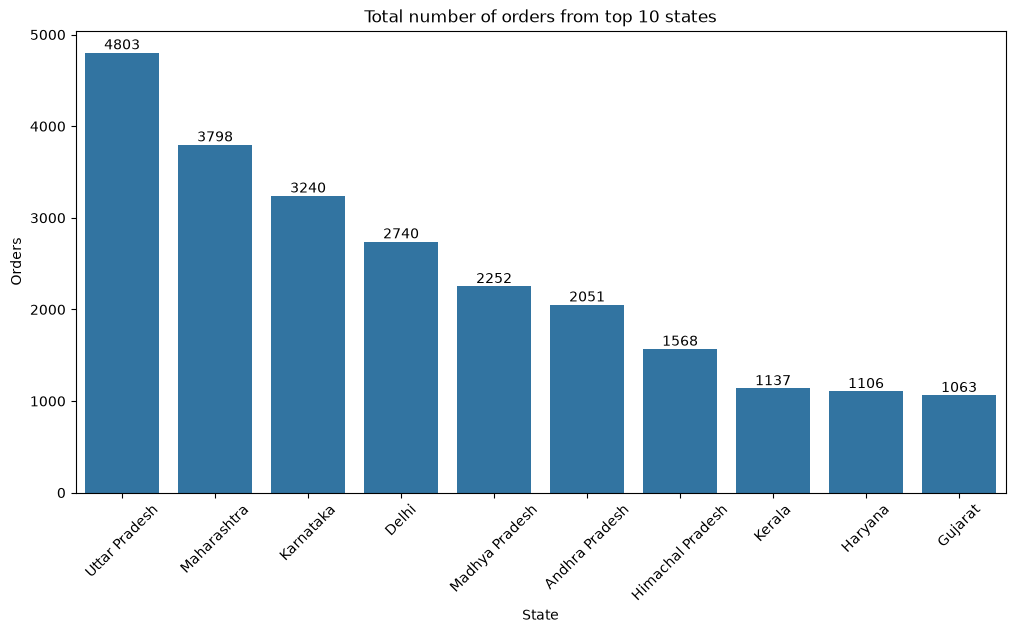

In [27]:
# Total number of orders from top 10 states
df2 = pd.DataFrame(df.groupby("State")["Orders"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
ax = sns.barplot(x="State",y="Orders",data=df2)
plt.title("Total number of orders from top 10 states")
plt.xticks(rotation=45)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

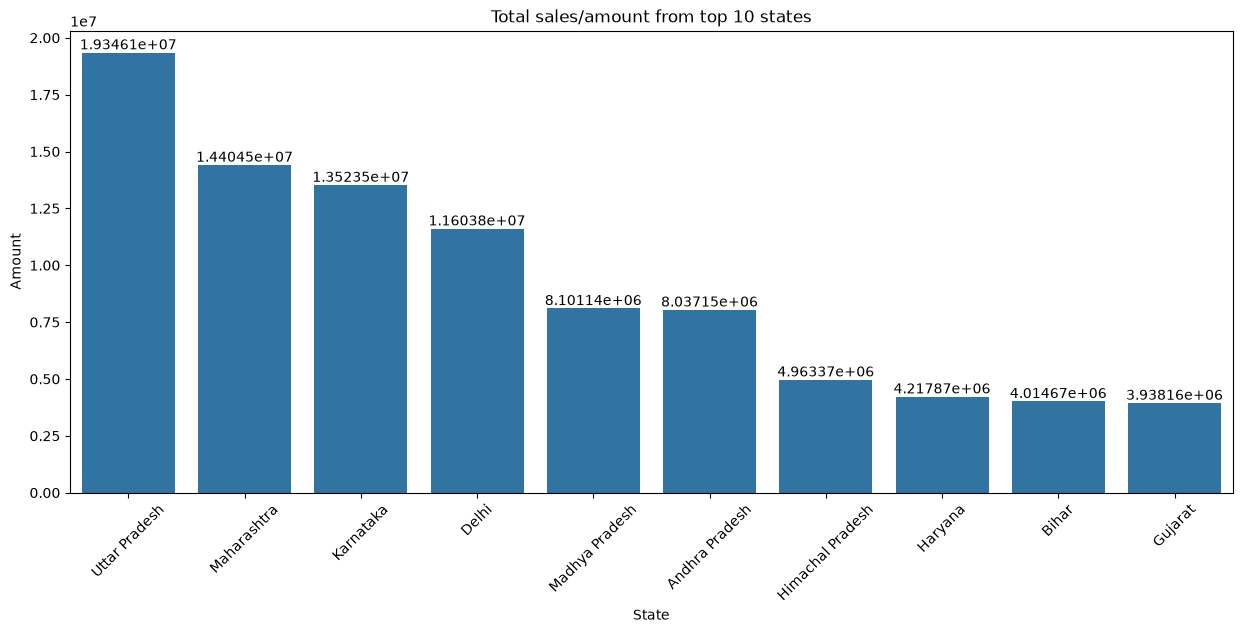

In [30]:
# Total amount/sales from top 10 states
df3 = pd.DataFrame(df.groupby("State")["Amount"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(15,6))
ax = sns.barplot(x="State",y="Amount",data=df3)
plt.title("Total sales/amount from top 10 states")
plt.xticks(rotation=45)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show() 

**From the above graphs we can see that most of the orders and total sales/amount are from Uttar Pradesh, Maharashtra, Karnataka**

### Marital Status

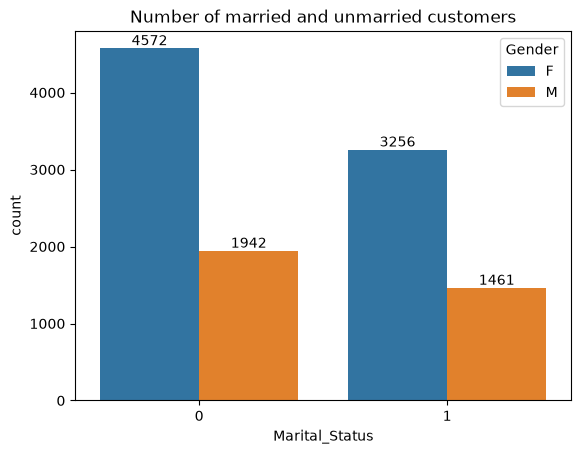

In [32]:
# Number of married and unmarried buyers
ax = sns.countplot(x="Marital_Status",hue="Gender",data=df)
plt.title("Number of married and unmarried customers")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

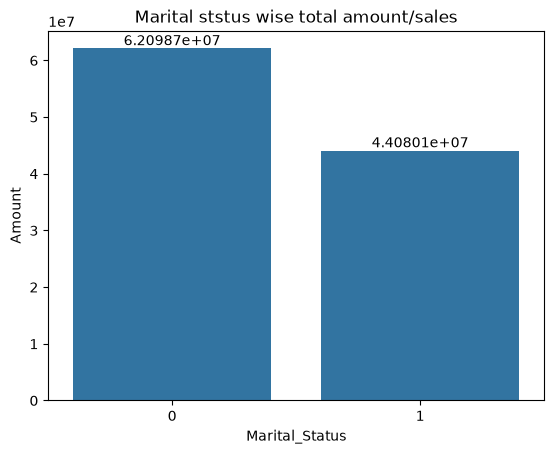

In [33]:
df4 = pd.DataFrame(df.groupby("Marital_Status")["Amount"].sum())
ax = sns.barplot(x="Marital_Status",y="Amount",data=df4)
plt.title("Marital ststus wise total amount/sales")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

**From the above graphs we can see that most of the buyers are married (women) and they have high purchasing power**

### Occupation

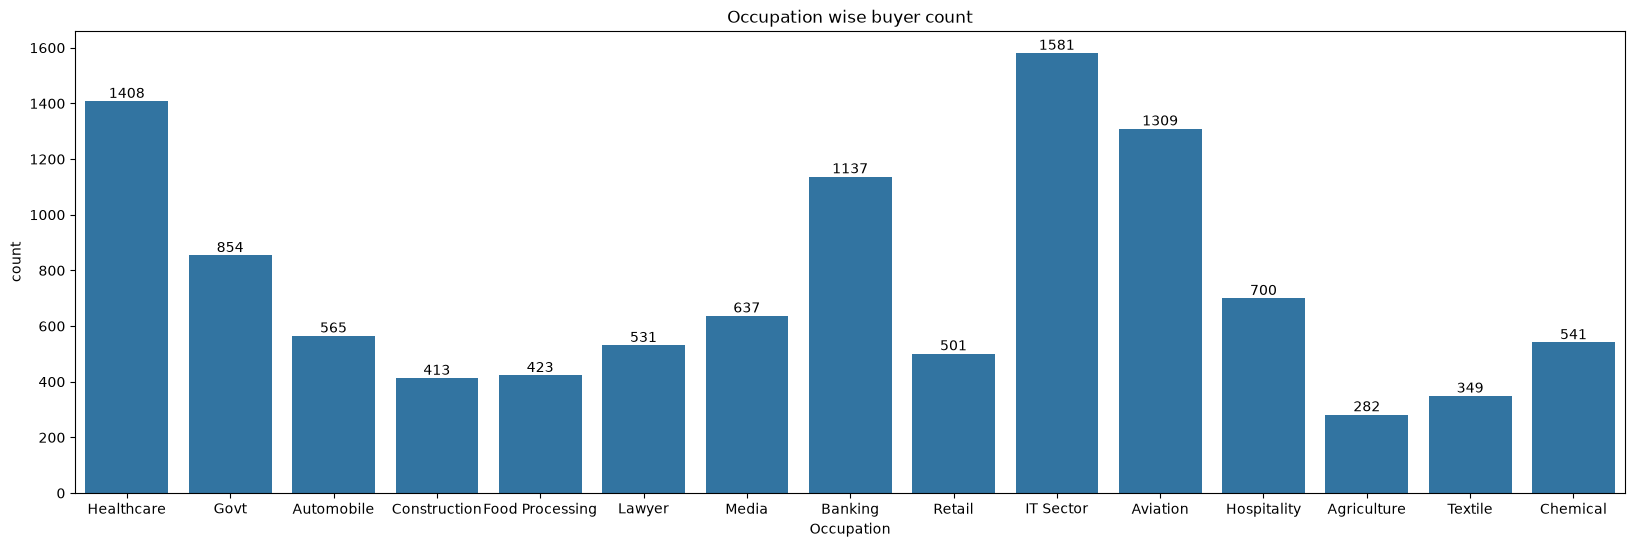

In [36]:
# Occupation wise customer count
plt.figure(figsize=(20,6))
ax = sns.countplot(x="Occupation",data=df)
plt.title("Occupation wise buyer count")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

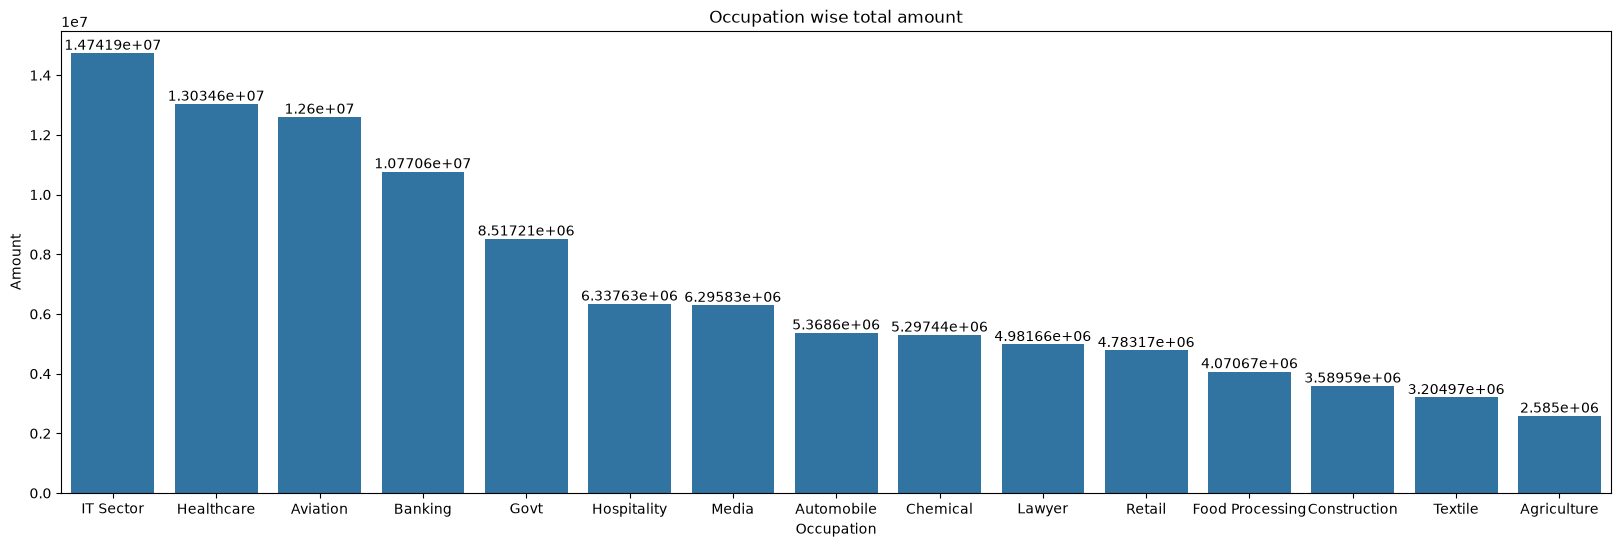

In [37]:
# Occupation wise total amount
df5 = pd.DataFrame(df.groupby("Occupation")["Amount"].sum().sort_values(ascending=False))
plt.figure(figsize=(20,6))
ax = sns.barplot(x="Occupation",y="Amount",data=df5)
plt.title("Occupation wise total amount")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

**From the above the graphs we can see that most of the buyers work in the IT, Healthcare and Aviation sector**

### Product Category

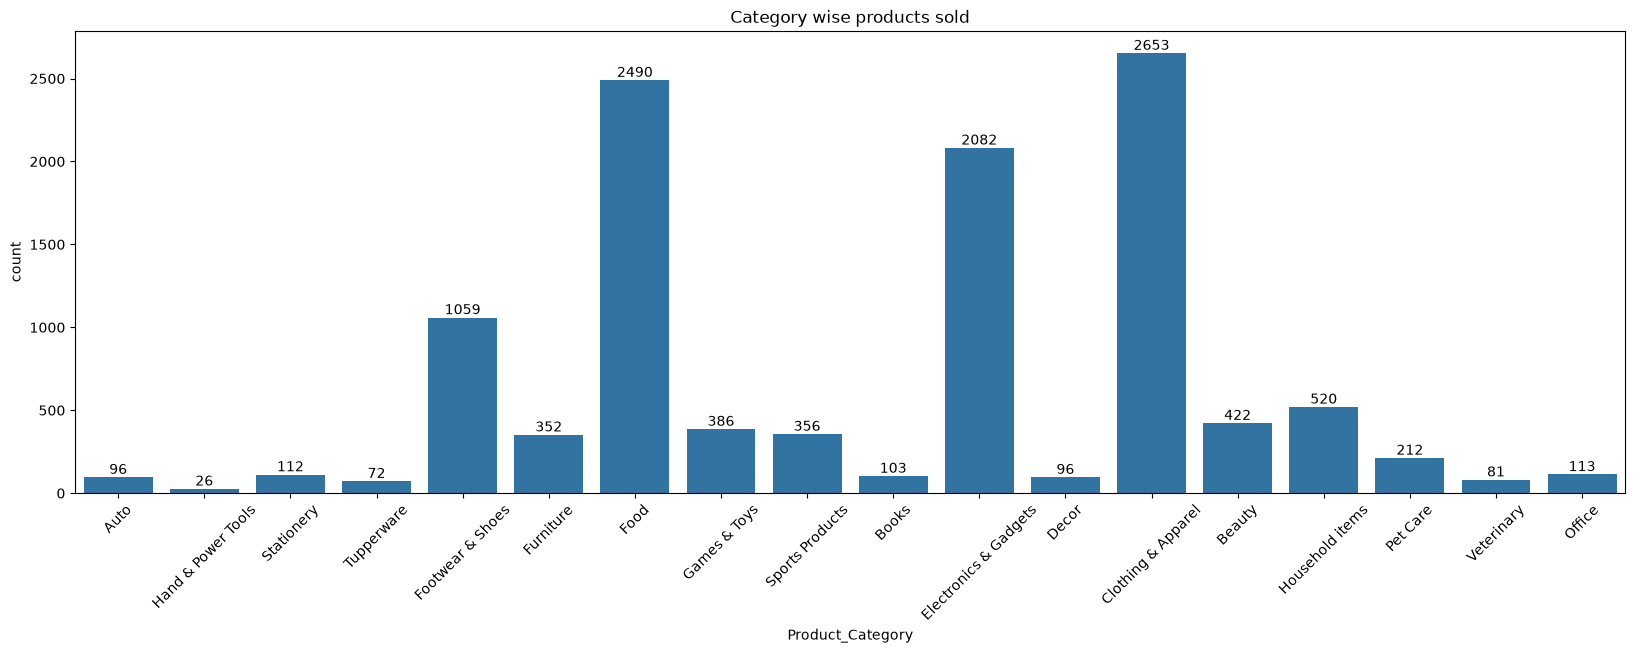

In [44]:
# Product category wise count
plt.figure(figsize=(20,6))
ax = sns.countplot(x="Product_Category",data=df)
plt.title("Category wise products sold")
plt.xticks(rotation=45)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

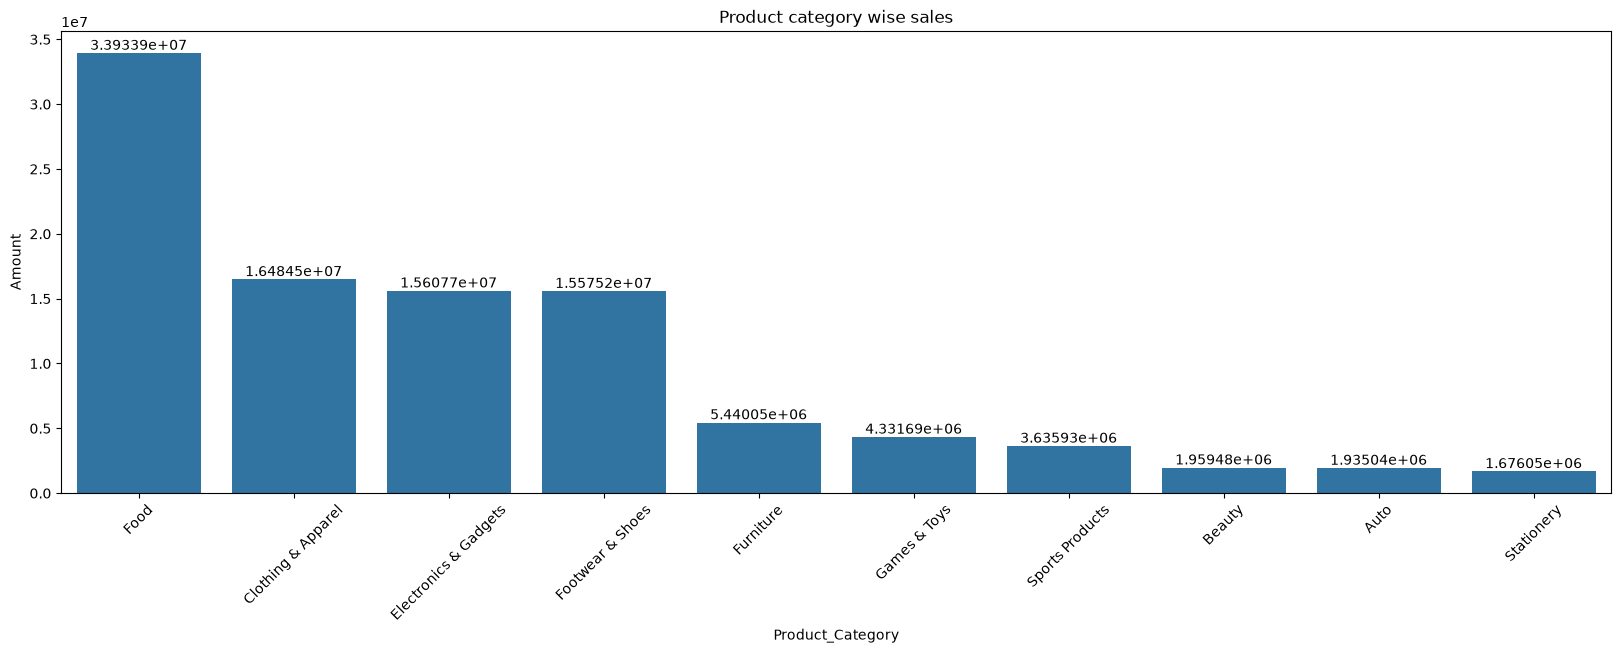

In [43]:
# Total amount/sales generated by top 10 product categories
df6 = pd.DataFrame(df.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(20,6))
ax = sns.barplot(x="Product_Category",y="Amount",data=df6)
plt.title("Product category wise sales")
plt.xticks(rotation=45)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()    

**From the above graphs we can see that most of the sold products are from "Food", "Clothing & Apparel" and "Electronics & Gadgets category"**

# Conclusion

**Married women age group 26-35 yrs from UP, Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category**